# Pertemuan 4 - Statistika Dasar & Analisis Data

**Nama Lengkap:** Suryani Tangdiaga

**NIM:** 250401020097

**Kelas:** Kelas IF405

## Tujuan Pembelajaran

1. Memahami statistik deskriptif.
2. Menganalisis distribusi data.
3. Menghitung korelasi Pearson dan Spearman.
4. Membuat visualisasi Histogram, Boxplot, Scatter Plot, dan Heatmap.
5. Melakukan eksplorasi data menggunakan dataset Iris.

In [10]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

In [2]:
df = sns.load_dataset("iris")

print("Shape :", df.shape)
print("\nTipe Data:")
print(df.dtypes)

df.head()

Shape : (150, 5)

Tipe Data:
sepal_length    float64
sepal_width     float64
petal_length    float64
petal_width     float64
species          object
dtype: object


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [3]:
df.describe().round(3)

,sepal_length,sepal_width,petal_length,petal_width
count,150.000,150.000,150.000,150.000
mean,5.843,3.057,3.758,1.199
std,0.828,0.436,1.765,0.762
min,4.300,2.000,1.000,0.100
25%,5.100,2.800,1.600,0.300
50%,5.800,3.000,4.350,1.300
75%,6.400,3.300,5.100,1.800
max,7.900,4.400,6.900,2.500


In [4]:
for col in df.select_dtypes(include='number').columns:

    print("="*40)
    print(col)

    print("Mean     :", round(df[col].mean(),3))
    print("Median   :", round(df[col].median(),3))
    print("Std Dev  :", round(df[col].std(),3))
    print("Varians  :", round(df[col].var(),3))
    print("Skewness :", round(df[col].skew(),3))
    print("Kurtosis :", round(df[col].kurt(),3))

sepal_length
Mean     : 5.843
Median   : 5.8
Std Dev  : 0.828
Varians  : 0.686
Skewness : 0.315
Kurtosis : -0.552
sepal_width
Mean     : 3.057
Median   : 3.0
Std Dev  : 0.436
Varians  : 0.19
Skewness : 0.319
Kurtosis : 0.228
petal_length
Mean     : 3.758
Median   : 4.35
Std Dev  : 1.765
Varians  : 3.116
Skewness : -0.275
Kurtosis : -1.402
petal_width
Mean     : 1.199
Median   : 1.3
Std Dev  : 0.762
Varians  : 0.581
Skewness : -0.103
Kurtosis : -1.341


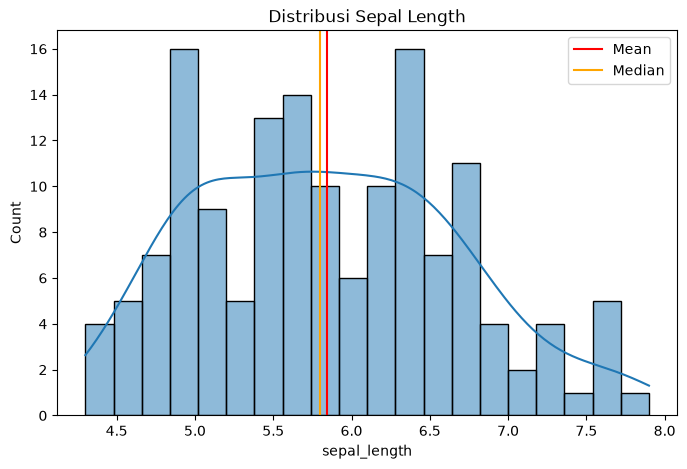

In [5]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["sepal_length"],
    kde=True,
    bins=20
)

plt.axvline(
    df["sepal_length"].mean(),
    color="red",
    label="Mean"
)

plt.axvline(
    df["sepal_length"].median(),
    color="orange",
    label="Median"
)

plt.title("Distribusi Sepal Length")
plt.legend()

plt.show()

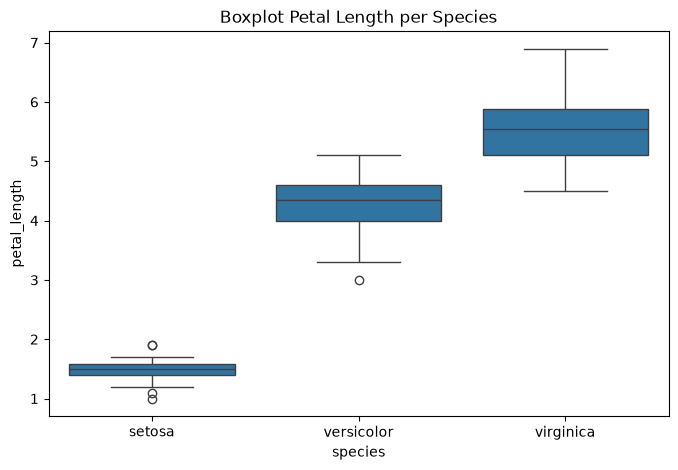

In [6]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="species",
    y="petal_length"
)

plt.title("Boxplot Petal Length per Species")

plt.show()

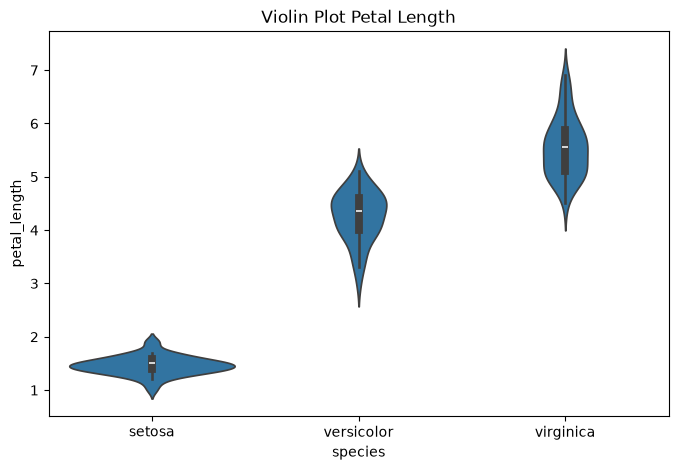

In [7]:
plt.figure(figsize=(8,5))

sns.violinplot(
    data=df,
    x="species",
    y="petal_length"
)

plt.title("Violin Plot Petal Length")

plt.show()

In [12]:
corr = df.drop("species", axis=1).corr()

corr

,sepal_length,sepal_width,petal_length,petal_width
sepal_length,1.000000,-0.117570,0.871754,0.817941
sepal_width,-0.117570,1.000000,-0.428440,-0.366126
petal_length,0.871754,-0.428440,1.000000,0.962865
petal_width,0.817941,-0.366126,0.962865,1.000000


In [16]:
mask = np.triu(np.ones(corr.shape)).astype(bool)

corr_masked = corr.mask(mask)

max_pair = corr_masked.stack().idxmax()

print("Pasangan korelasi tertinggi:")
print(max_pair)

print("\nNilai Korelasi:")
print(corr.loc[max_pair])

Pasangan korelasi tertinggi:
('petal_width', 'petal_length')

Nilai Korelasi:
0.962865431402796


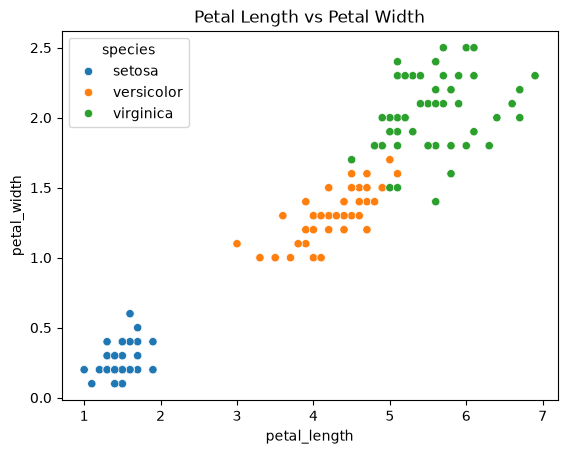

In [17]:
sns.scatterplot(
    data=df,
    x="petal_length",
    y="petal_width",
    hue="species"
)

plt.title("Petal Length vs Petal Width")

plt.show()

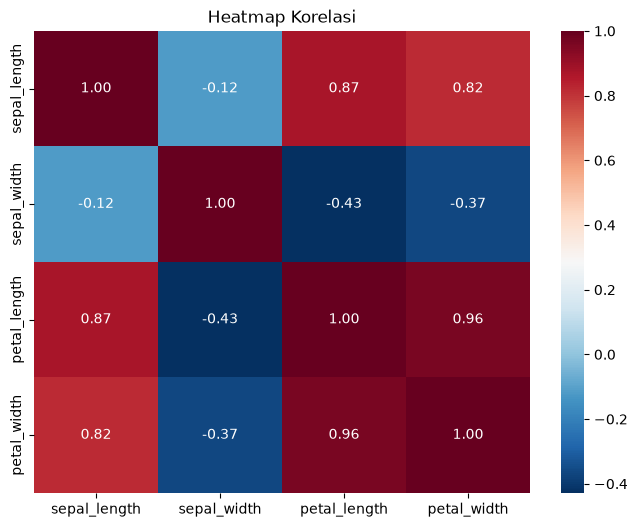

In [18]:
plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r"
)

plt.title("Heatmap Korelasi")

plt.show()

## Kesimpulan

1. Dataset Iris memiliki 150 baris dan 5 kolom.
2. Statistik deskriptif menunjukkan nilai mean, median, standar deviasi, skewness, dan kurtosis setiap variabel.
3. Histogram menunjukkan distribusi data sepal_length mendekati distribusi normal.
4. Boxplot dan violin plot memperlihatkan perbedaan karakteristik petal_length pada setiap spesies.
5. Korelasi tertinggi ditemukan pada variabel petal_length dan petal_width.
6. Heatmap memudahkan identifikasi hubungan antar variabel numerik dalam dataset Iris.